# TS - Autoregressive Model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import ar_select_order
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [4]:
df = pd.read_csv('../Data/SP500_PCH_Weekly_Avg.csv')
df.head()

,observation_date,SP500_PCH
0,2016-01-09,-4.05670
1,2016-01-16,-3.33797
2,2016-01-23,-1.66526
3,2016-01-30,1.08105
4,2016-02-06,0.55995


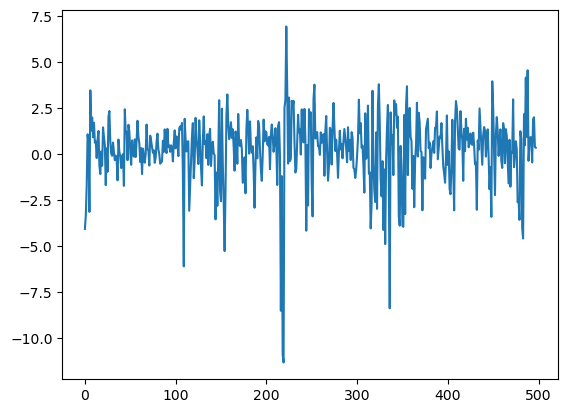

In [75]:
plt.plot(df['SP500_PCH'])

In [77]:
#Convert observation_date to datetime and set as index
df['observation_date'] = pd.to_datetime(df['observation_date'])
df.set_index('observation_date', inplace=True)

#Check for missing values
missing_new = df.isna().sum()
print(missing_new)

SP500_PCH    0
dtype: int64


In [6]:
#ADF Test for stationarity
adf_result = adfuller(df['SP500_PCH'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4g}")
if adf_result[1] < 0.05:
    print("Series is stationary (reject null hypothesis).")
else:
    print("Series is NOT stationary (cannot reject null hypothesis).")

ADF Statistic: -17.5049
p-value: 4.365e-30
Series is stationary (reject null hypothesis).


In [81]:
#Split for testing / training 
train = df.iloc[:-30]
test = df.iloc[-30:]

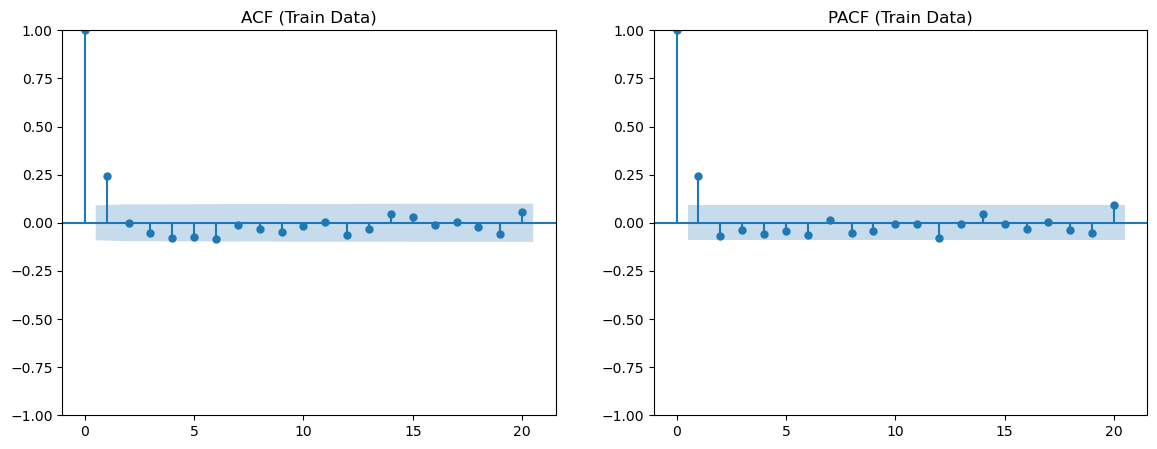

In [97]:
#Plot ACF and PACF for training data
fig, ax = plt.subplots(1, 2, figsize=(14,5))
plot_acf(train['SP500_PCH'], lags=20, ax=ax[0])
plot_pacf(train['SP500_PCH'], lags=20, ax=ax[1])
ax[0].set_title('ACF (Train Data)')
ax[1].set_title('PACF (Train Data)')
plt.show()

In [83]:
#Auto select lag order based on AIC
aic_auto = ar_select_order(train['SP500_PCH'], maxlag=10, ic='aic', old_names=False)
aic_auto_model = aic_auto.model.fit()
aic_auto_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              SP500_PCH   No. Observations:                  468
Model:                     AutoReg(2)   Log Likelihood                -925.644
Method:               Conditional MLE   S.D. of innovations              1.764
Date:                Mon, 21 Jul 2025   AIC                           1859.288
Time:                        11:34:36   BIC                           1875.865
Sample:                    01-23-2016   HQIC                          1865.812
                         - 12-21-2024                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2120      0.083      2.556      0.011       0.049       0.375
SP500_PCH.L1     0.2544      0.046      5.511      0.000       0.164       0.345
SP500_PCH.L2    -0.0653      0.046     -1.423      0.155      -0.155       0.025
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.9473           -3.3935j            3.9125           -0.1671
AR.2            1.9473           +3.3935j            3.9125            0.1671
-----------------------------------------------------------------------------
"""

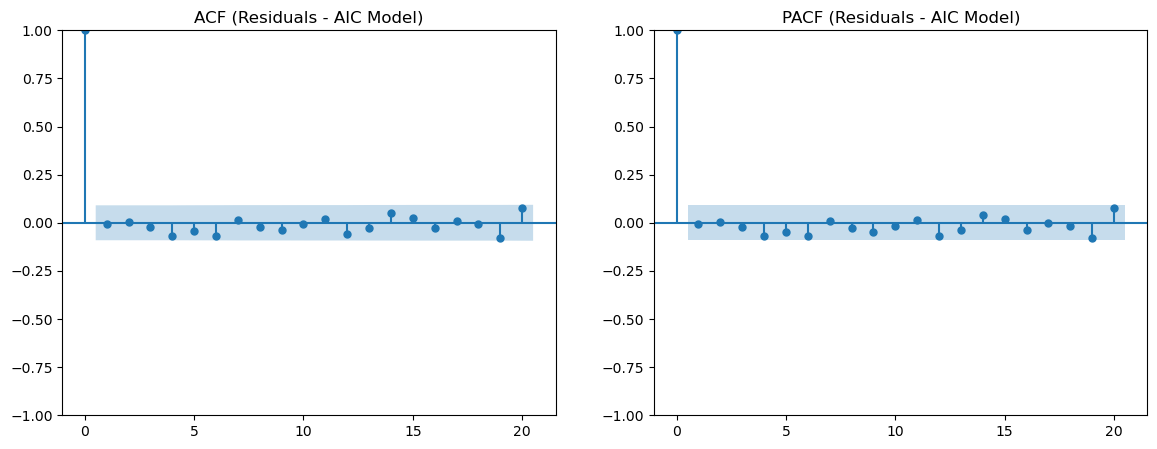

\nLjung-Box test for AIC model residuals:
     lb_stat  lb_pvalue
10  6.435219    0.77747


In [123]:
#Residual diagnostics for AIC model
aic_resid = aic_auto_model.resid
fig, ax = plt.subplots(1, 2, figsize=(14,5))
plot_acf(aic_resid, lags=20, ax=ax[0])
plot_pacf(aic_resid, lags=20, ax=ax[1])
ax[0].set_title('ACF (Residuals - AIC Model)')
ax[1].set_title('PACF (Residuals - AIC Model)')
plt.show()

ljung_aic = acorr_ljungbox(aic_resid, lags=[10], return_df=True)
print("\\nLjung-Box test for AIC model residuals:")
print(ljung_aic)

In [101]:
aic_forecast = aic_auto_model.predict(start=len(train), end=len(train) + len(test) - 1)
aic_forecast.index = test.index
aic_forecast

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


observation_date
2024-12-28   -0.174873
2025-01-04    0.271015
2025-01-11    0.292410
2025-01-18    0.268725
2025-01-25    0.261301
2025-02-01    0.260960
2025-02-08    0.261358
2025-02-15    0.261481
2025-02-22    0.261487
2025-03-01    0.261480
2025-03-08    0.261478
2025-03-15    0.261478
2025-03-22    0.261478
2025-03-29    0.261478
2025-04-05    0.261478
2025-04-12    0.261478
2025-04-19    0.261478
2025-04-26    0.261478
2025-05-03    0.261478
2025-05-10    0.261478
2025-05-17    0.261478
2025-05-24    0.261478
2025-05-31    0.261478
2025-06-07    0.261478
2025-06-14    0.261478
2025-06-21    0.261478
2025-06-28    0.261478
2025-07-05    0.261478
2025-07-12    0.261478
2025-07-19    0.261478
dtype: float64

In [87]:
#Auto select lag order based on BIC
bic_auto = ar_select_order(train['SP500_PCH'], maxlag=10, ic='bic', old_names=False)
bic_auto_model = bic_auto.model.fit()
bic_auto_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              SP500_PCH   No. Observations:                  468
Model:                     AutoReg(1)   Log Likelihood                -929.186
Method:               Conditional MLE   S.D. of innovations              1.770
Date:                Mon, 21 Jul 2025   AIC                           1864.372
Time:                        11:34:39   BIC                           1876.811
Sample:                    01-16-2016   HQIC                          1869.267
                         - 12-21-2024                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1927      0.083      2.331      0.020       0.031       0.355
SP500_PCH.L1     0.2453      0.045      5.496      0.000       0.158       0.333
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            4.0770           +0.0000j            4.0770            0.0000
-----------------------------------------------------------------------------
"""

In [105]:
bic_forecast = bic_auto_model.predict(start=len(train), end=len(train) + len(test) - 1)
bic_forecast.index = test.index
bic_forecast

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


observation_date
2024-12-28   -0.195839
2025-01-04    0.144624
2025-01-11    0.228133
2025-01-18    0.248616
2025-01-25    0.253640
2025-02-01    0.254872
2025-02-08    0.255175
2025-02-15    0.255249
2025-02-22    0.255267
2025-03-01    0.255271
2025-03-08    0.255272
2025-03-15    0.255273
2025-03-22    0.255273
2025-03-29    0.255273
2025-04-05    0.255273
2025-04-12    0.255273
2025-04-19    0.255273
2025-04-26    0.255273
2025-05-03    0.255273
2025-05-10    0.255273
2025-05-17    0.255273
2025-05-24    0.255273
2025-05-31    0.255273
2025-06-07    0.255273
2025-06-14    0.255273
2025-06-21    0.255273
2025-06-28    0.255273
2025-07-05    0.255273
2025-07-12    0.255273
2025-07-19    0.255273
dtype: float64

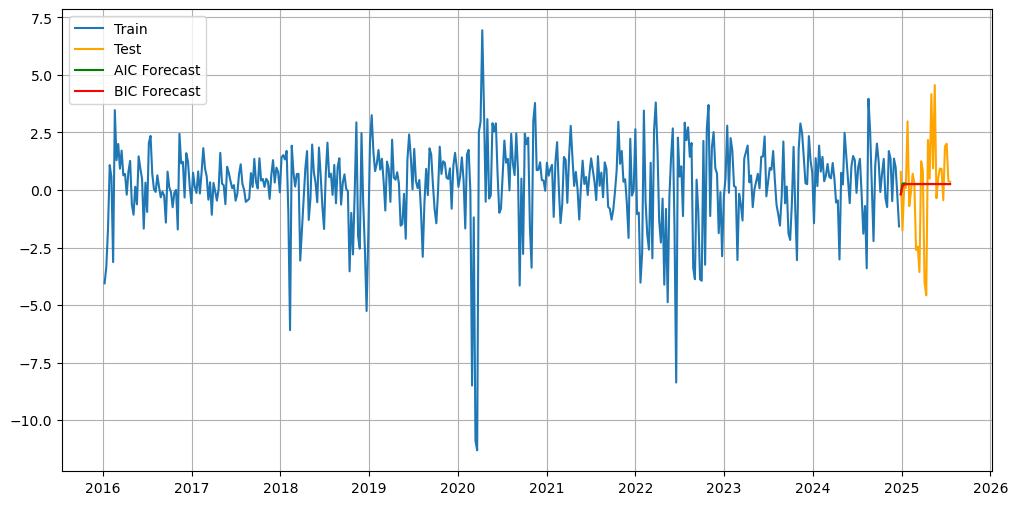

In [91]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['SP500_PCH'], label='Train')
plt.plot(test.index, test['SP500_PCH'], label='Test', color='orange')
plt.plot(test.index, aic_auto_forecast, label='AIC Forecast', color='green')
plt.plot(test.index, bic_auto_forecast, label='BIC Forecast', color='red')
plt.legend()
plt.grid(True)
plt.show()

In [125]:
#Function to evaluate forecast accuracy 
def forecast_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

aic_rmse, aic_mae = forecast_metrics(test['SP500_PCH'], aic_forecast)
bic_rmse, bic_mae = forecast_metrics(test['SP500_PCH'], bic_forecast)

print(f"AIC Model - RMSE: {aic_rmse}, MAE: {aic_mae}")
print(f"BIC Model - RMSE: {bic_rmse}, MAE: {bic_mae}")

AIC Model - RMSE: 2.100898559693326, MAE: 1.514727536161782
BIC Model - RMSE: 2.097131477359742, MAE: 1.5101096893627703
